In [17]:
!nvidia-smi

Thu Oct  1 09:54:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             36W /   70W |     109MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [18]:
import time
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda

In [19]:
from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

Saving cat.png to cat (1).png


(491, 553, 3) 271523 pixels


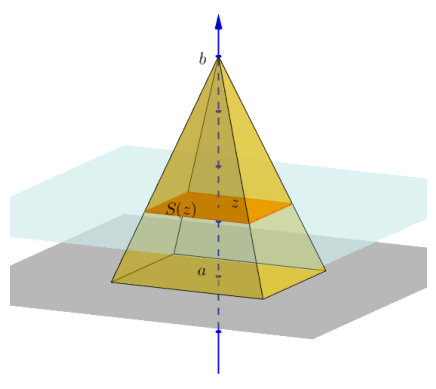

In [20]:
src = plt.imread(fname)

if src.dtype != np.uint8:
    src = (src * 255).astype(np.uint8)
if src.shape[2] == 4:
    src = np.ascontiguousarray(src[:, :, :3])

imageHeight, imageWidth = src.shape[0], src.shape[1]
pixelCount = imageHeight * imageWidth
print(src.shape, pixelCount, 'pixels')

plt.imshow(src)
plt.axis('off')
plt.show()

In [21]:
def grayscaleCPU(src, dst):
    for y in range(src.shape[0]):
        for x in range(src.shape[1]):
            g = (int(src[y, x, 0]) + int(src[y, x, 1]) + int(src[y, x, 2])) // 3
            dst[y, x, 0] = dst[y, x, 1] = dst[y, x, 2] = g


hostDst = np.zeros_like(src)

start = time.time()
grayscaleCPU(src, hostDst)
cpuTime = time.time() - start
print('CPU: %.4f s' % cpuTime)

CPU: 0.2860 s


In [22]:
@cuda.jit
def grayscale1D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx < src.shape[0]:
        g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
        dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g


flatSrc = np.ascontiguousarray(src.reshape(pixelCount, 3))
devFlatSrc = cuda.to_device(flatSrc)
devFlatDst = cuda.device_array((pixelCount, 3), np.uint8)

blockSize1D = 64
gridSize1D = (pixelCount + blockSize1D - 1) // blockSize1D

grayscale1D[gridSize1D, blockSize1D](devFlatSrc, devFlatDst)
cuda.synchronize()

start = time.time()
for _ in range(20):
    grayscale1D[gridSize1D, blockSize1D](devFlatSrc, devFlatDst)
cuda.synchronize()
time1D = (time.time() - start) / 20

print('1D, block %d: %.6f s, speedup %.0fx' % (blockSize1D, time1D, cpuTime / time1D))

1D, block 64: 0.000084 s, speedup 3424x


In [23]:
@cuda.jit
def grayscale2D(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    tidy = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if tidx < src.shape[1] and tidy < src.shape[0]:
        g = np.uint8((src[tidy, tidx, 0] + src[tidy, tidx, 1] + src[tidy, tidx, 2]) / 3)
        dst[tidy, tidx, 0] = dst[tidy, tidx, 1] = dst[tidy, tidx, 2] = g

In [24]:
devSrc = cuda.to_device(src)
devDst = cuda.device_array(src.shape, np.uint8)

blockSize = (32, 32)
gridSize = ((imageWidth + blockSize[0] - 1) // blockSize[0],
            (imageHeight + blockSize[1] - 1) // blockSize[1])
print(gridSize, blockSize)

grayscale2D[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()

start = time.time()
for _ in range(20):
    grayscale2D[gridSize, blockSize](devSrc, devDst)
cuda.synchronize()
time2D = (time.time() - start) / 20

hostDst2 = devDst.copy_to_host()
print('2D, block %s: %.6f s, speedup %.0fx' % (blockSize, time2D, cpuTime / time2D))

(18, 16) (32, 32)
2D, block (32, 32): 0.000094 s, speedup 3051x


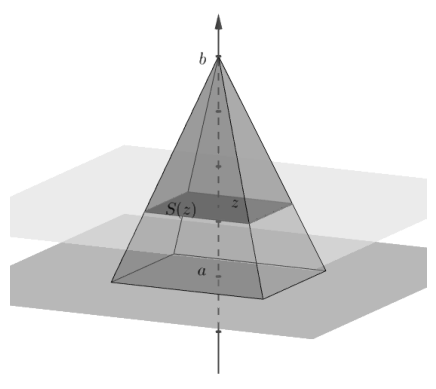

True
True


In [25]:
plt.imshow(hostDst2)
plt.axis('off')
plt.show()

print(np.array_equal(hostDst, hostDst2))
print(np.array_equal(devFlatDst.copy_to_host().reshape(src.shape), hostDst2))

In [26]:
blockSizes = [(1, 1), (2, 2), (4, 4), (8, 8), (16, 16), (32, 32),
              (32, 1), (32, 2), (32, 4), (32, 8), (32, 16),
              (8, 32), (16, 8), (64, 16)]

times = []
speedups = []

for bs in blockSizes:
    gs = ((imageWidth + bs[0] - 1) // bs[0],
          (imageHeight + bs[1] - 1) // bs[1])

    grayscale2D[gs, bs](devSrc, devDst)   # warm up
    cuda.synchronize()

    start = time.time()
    for _ in range(20):
        grayscale2D[gs, bs](devSrc, devDst)
    cuda.synchronize()
    t = (time.time() - start) / 20

    times.append(t)
    speedups.append(cpuTime / t)
    print('%-9s %4d threads  %.6f s  %7.0fx' % (bs, bs[0] * bs[1], t, cpuTime / t))

(1, 1)       1 threads  0.002116 s      135x
(2, 2)       4 threads  0.000539 s      530x
(4, 4)      16 threads  0.000141 s     2028x
(8, 8)      64 threads  0.000075 s     3807x
(16, 16)   256 threads  0.000076 s     3776x
(32, 32)  1024 threads  0.000084 s     3387x
(32, 1)     32 threads  0.000077 s     3715x
(32, 2)     64 threads  0.000077 s     3719x
(32, 4)    128 threads  0.000077 s     3712x
(32, 8)    256 threads  0.000077 s     3704x
(32, 16)   512 threads  0.000079 s     3627x
(8, 32)    256 threads  0.000075 s     3810x
(16, 8)    128 threads  0.000075 s     3802x
(64, 16)  1024 threads  0.000083 s     3430x


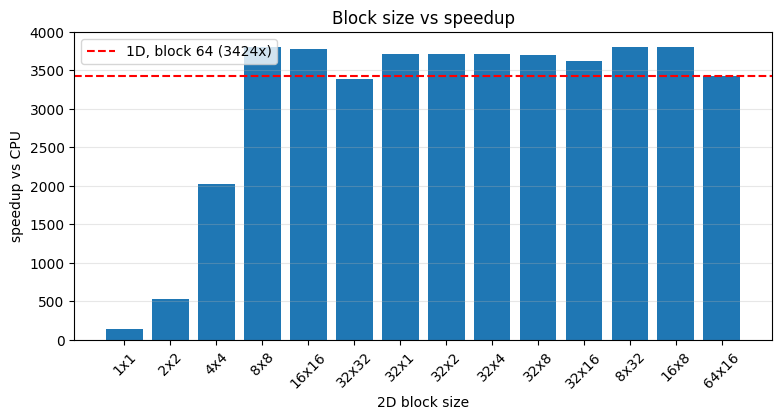

nhanh nhat: (8, 32) 3810x
cham nhat: (1, 1) 135x
1D:        3424x


In [27]:
labels = ['%dx%d' % bs for bs in blockSizes]

plt.figure(figsize=(9, 4))
plt.bar(labels, speedups)
plt.axhline(cpuTime / time1D, color='red', linestyle='--',
            label='1D, block 64 (%.0fx)' % (cpuTime / time1D))
plt.ylabel('speedup vs CPU')
plt.xlabel('2D block size')
plt.title('Block size vs speedup')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.savefig('blocksize2d.png', dpi=150, bbox_inches='tight')
plt.show()

best = blockSizes[int(np.argmax(speedups))]
print('nhanh nhat:', best, '%.0fx' % max(speedups))
print('cham nhat:', blockSizes[int(np.argmin(speedups))], '%.0fx' % min(speedups))
print('1D:        %.0fx' % (cpuTime / time1D))

In [28]:
plt.imsave('gray2d.png', hostDst2)
files.download('blocksize2d.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>